In [197]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [224]:
X, y = make_circles(n_samples = 1000, random_state = 42, noise = 0.03)

In [225]:
df = pd.DataFrame(X, y)
X.shape, y.shape

((1000, 2), (1000,))

In [226]:
X_reduced = PCA(n_components = 2).fit_transform(X)

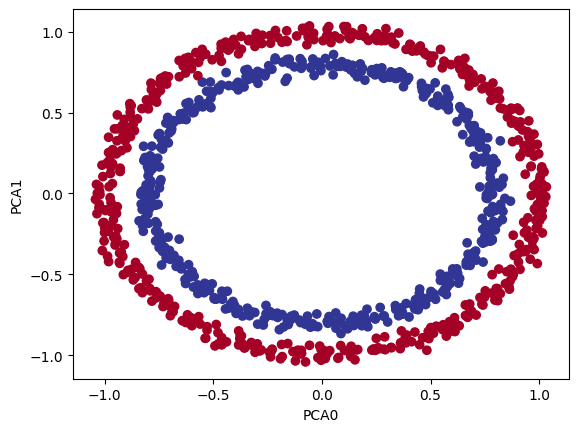

In [227]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("PCA0")
plt.ylabel("PCA1")
plt.show()

In [228]:
## Turning ndarray(numpy array) into torch.tensor

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [229]:
# Train,Test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [230]:
X_train.shape

torch.Size([800, 2])

In [231]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [232]:
class MultiLayerClassifier(torch.nn.Module):
    def __init__(self):
        super().__init__()

        ## Linear Layer (multi)
        self.layer_1 = torch.nn.Linear(
            in_features = 2, out_features = 64,
        )
        self.layer_2 = torch.nn.ReLU()
        self.layer_3 = torch.nn.Linear(
            in_features = 64, out_features = 1
        )

        ## Method 2 (sequential layer)
        # self.seq_layer = torch.nn.Sequential(
        #     torch.nn.Linear(
        #         in_features = 2, out_features = 5
        #    ),
        #     torch.nn.Linear(
        #         in_features = 5, out_features = 1
        #     )
        # )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.layer_2(self.layer_1(x)))

In [233]:
model = MultiLayerClassifier().to(device)
model

MultiLayerClassifier(
  (layer_1): Linear(in_features=2, out_features=64, bias=True)
  (layer_2): ReLU()
  (layer_3): Linear(in_features=64, out_features=1, bias=True)
)

In [234]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802],
                      [-0.3258, -0.0829],
                      [-0.2872,  0.4691],
                      [-0.5582, -0.3260],
                      [-0.1997, -0.4252],
                      [ 0.0667, -0.6984],
                      [ 0.6386, -0.6007],
                      [ 0.5459,  0.1177],
                      [-0.2296,  0.4370],
                      [ 0.1102,  0.5713],
                      [ 0.0773, -0.2230],
                      [ 0.1900, -0.1918],
                      [ 0.2976,  0.6313],
                      [ 0.4087, -0.3091],
  

In [235]:
with torch.inference_mode():
    y_pred = model(X_test.to(device))

In [236]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802],
                      [-0.3258, -0.0829],
                      [-0.2872,  0.4691],
                      [-0.5582, -0.3260],
                      [-0.1997, -0.4252],
                      [ 0.0667, -0.6984],
                      [ 0.6386, -0.6007],
                      [ 0.5459,  0.1177],
                      [-0.2296,  0.4370],
                      [ 0.1102,  0.5713],
                      [ 0.0773, -0.2230],
                      [ 0.1900, -0.1918],
                      [ 0.2976,  0.6313],
                      [ 0.4087, -0.3091],
  

In [237]:
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.01)

In [238]:
def accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct/len(y_pred)) * 100

In [239]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test.to(device))

y_logits[:5]

tensor([[ 0.2730],
        [ 0.3364],
        [-0.2626],
        [ 0.3575],
        [-0.2985]], device='mps:0')

In [240]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [215]:
_y_label = torch.round(y_logits[:5])
torch.eq(y_test[:5].to(device), _y_label[:5]) 

tensor([[False,  True, False,  True, False],
        [False,  True, False,  True, False],
        [False,  True, False,  True, False],
        [False,  True, False,  True, False],
        [False,  True, False,  True, False]], device='mps:0')

In [216]:
y_preds_prob = model(X_train.to(device)).sigmoid()
torch.round(y_preds_prob[:5]).squeeze()

tensor([1., 0., 0., 0., 1.], device='mps:0', grad_fn=<SqueezeBackward0>)

In [217]:
y_preds_logit = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))
y_preds_logit.squeeze()

tensor([0., 1., 0., 1., 0.], device='mps:0', grad_fn=<SqueezeBackward0>)

In [218]:
torch.mps.manual_seed(42)
torch.manual_seed(42)

In [219]:
epochs = 1000
epoch_loop = []
losses = []
test_losses = []

## Training Loop
for epoch in range(epochs):
    model.train()

    ## 1. Forward Pass
    y_pred_probs = model(X_train.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_pred_probs))

    ## 2. Calculating Model Accuracy
    model_acc = accuracy(y_train.to(device), y_pred)

    ## 3. Loss & Optimization
    loss = loss_fn(y_pred_probs, y_train.to(device))
    optimizer.zero_grad()

    # Backpropogation
    loss.backward()
    # Gradiant Decent
    optimizer.step()

    losses.append(loss.item())

    # Model Evaluation (Testing Model Prediction) on Test Data
    model.eval()
    with torch.inference_mode():
        test_y_pred_probs = model(X_test.to(device)).squeeze()
        test_y_pred = torch.round(torch.sigmoid(test_y_pred_probs))

        # Test losses
        test_loss = loss_fn(test_y_pred_probs, y_test.to(device))
        # Model Accuracy
        acc = accuracy(y_test.to(device), test_y_pred)
        test_losses.append(test_loss)
        
    epoch_loop.append(epoch)
    if epoch % 100 == 0:
        print(f"Losses: {loss:.5f} | Test Losses: {test_loss:.5f}")
        print(f"Model Accuracy: Train Data: {model_acc} | Test Data: {acc}\n")

Losses: 0.69621 | Test Losses: 0.69839
Model Accuracy: Train Data: 50.5 | Test Data: 47.5

Losses: 0.10890 | Test Losses: 0.14509
Model Accuracy: Train Data: 100.0 | Test Data: 100.0

Losses: 0.02515 | Test Losses: 0.04667
Model Accuracy: Train Data: 100.0 | Test Data: 100.0

Losses: 0.01203 | Test Losses: 0.02752
Model Accuracy: Train Data: 100.0 | Test Data: 100.0

Losses: 0.00735 | Test Losses: 0.01941
Model Accuracy: Train Data: 100.0 | Test Data: 100.0

Losses: 0.00500 | Test Losses: 0.01498
Model Accuracy: Train Data: 100.0 | Test Data: 100.0

Losses: 0.00367 | Test Losses: 0.01225
Model Accuracy: Train Data: 100.0 | Test Data: 100.0

Losses: 0.00283 | Test Losses: 0.01040
Model Accuracy: Train Data: 100.0 | Test Data: 100.0

Losses: 0.00225 | Test Losses: 0.00904
Model Accuracy: Train Data: 100.0 | Test Data: 100.0

Losses: 0.00182 | Test Losses: 0.00801
Model Accuracy: Train Data: 100.0 | Test Data: 100.0



In [220]:
X_train[:5]

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        [-0.9666, -0.2256],
        [-0.1666,  0.7994]])

In [221]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [222]:
import requests
from pathlib import Path

path = Path("helper_function.py")
if path.exists():
  print("File already exists")
    
response = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
with open(path, 'wb') as f:
    f.write(response.content)

File already exists


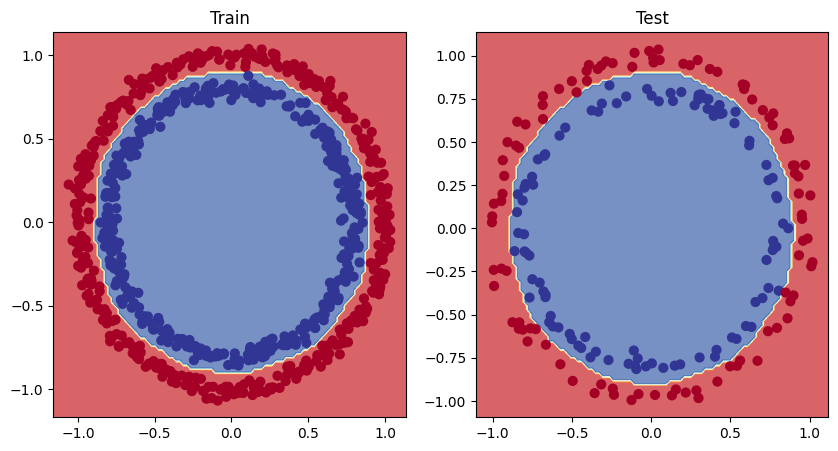

In [223]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In [196]:
torch.manual_seed(42)

m = torch.nn.ReLU()
num = torch.randn(2)
m(num)

tensor([0.3367, 0.1288])

In [190]:
num

tensor([0.3367, 0.1288])

In [248]:
X.dim(), y.dim()

(2, 1)

In [252]:
## Expermenting Model to improve it's Accuracy & Prediction

class CircleModelV1(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = torch.nn.Linear(
            in_features = 2, out_features = 10
        )
        self.layer_2 = torch.nn.Linear(
            in_features = 10, out_features = 10
        )
        self.layer_3 = torch.nn.Linear(
            in_features = 10, out_features = 1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.layer_2(self.layer_1(x)))
        

In [253]:
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [254]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.3594,  0.2203],
                      [-0.2058, -0.2766],
                      [ 0.6742,  0.2463],
                      [ 0.5041, -0.3423],
                      [-0.2888,  0.2599],
                      [-0.4711, -0.4622],
                      [-0.0342, -0.2586],
                      [-0.5301,  0.4194],
                      [ 0.5686,  0.1147],
                      [-0.1231, -0.6550]], device='mps:0')),
             ('layer_1.bias',
              tensor([-0.2576,  0.1800,  0.3334, -0.0894, -0.2796,  0.3940, -0.5631,  0.4469,
                      -0.2743,  0.0108], device='mps:0')),
             ('layer_2.weight',
              tensor([[-0.0625,  0.0383, -0.0956,  0.2299, -0.0082,  0.2468,  0.3040, -0.1541,
                       -0.2307,  0.2537],
                      [ 0.2478, -0.2415, -0.0244, -0.3118, -0.2589,  0.0611,  0.0841,  0.0670,
                       -0.0861,  0.2917],
                      [ 0.0452, -0.1866,

In [258]:
# Experiment 1 Increasing the Parameters & hidden uints

loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr=0.01)

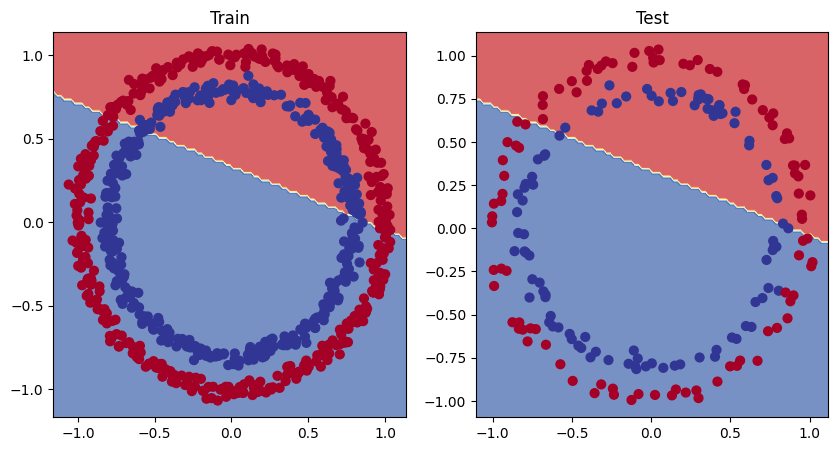

In [259]:
# Plotting the Graph & Prediction with Random Data's

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [267]:
# Model Training

epochs = 100 # 100 Training loop

for epoch in range(epochs):
    model.train()

    ## 1. Forward pass to the Model
    y_sigmoid = model(X_train.to(device)).squeeze() 
    y_pred = torch.round(torch.sigmoid(y_sigmoid))

    ## Calculating Model Accuracy
    train_model_accuracy = accuracy(y_train.to(device), y_pred)

    ## 2. Loss Function & Optimizer zero_grad
    loss = loss_fn(y_sigmoid, y_train.to(device))
    optimizer.zero_grad()

    ## 3. Backpropogation
    loss.backward()

    ## 4. Gradiant Decent
    optimizer.step()

    ## Model Evaluation on Test data
    model.eval()
    with torch.inference_mode():
        y_test_sigmoid = model(X_test.to(device)).squeeze()
        y_test_pred = torch.round(torch.sigmoid(y_test_sigmoid))

        test_model_accuracy = accuracy(y_test.to(device), y_test_pred)
        test_loss = loss_fn(y_test_sigmoid, y_test.to(device))

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")
        print(f"Train Model Accuracy: {train_model_accuracy} | Test Model Accuracy {test_model_accuracy}\n")

Epoch 0 | Train Loss: 0.69549 | Test Loss: 0.71011
Train Model Accuracy: 50.875 | Test Model Accuracy 47.0

Epoch 10 | Train Loss: 0.69549 | Test Loss: 0.71011
Train Model Accuracy: 50.875 | Test Model Accuracy 47.0

Epoch 20 | Train Loss: 0.69549 | Test Loss: 0.71011
Train Model Accuracy: 50.875 | Test Model Accuracy 47.0

Epoch 30 | Train Loss: 0.69549 | Test Loss: 0.71011
Train Model Accuracy: 50.875 | Test Model Accuracy 47.0

Epoch 40 | Train Loss: 0.69549 | Test Loss: 0.71011
Train Model Accuracy: 50.875 | Test Model Accuracy 47.0

Epoch 50 | Train Loss: 0.69549 | Test Loss: 0.71011
Train Model Accuracy: 50.875 | Test Model Accuracy 47.0

Epoch 60 | Train Loss: 0.69549 | Test Loss: 0.71011
Train Model Accuracy: 50.875 | Test Model Accuracy 47.0

Epoch 70 | Train Loss: 0.69549 | Test Loss: 0.71011
Train Model Accuracy: 50.875 | Test Model Accuracy 47.0

Epoch 80 | Train Loss: 0.69549 | Test Loss: 0.71011
Train Model Accuracy: 50.875 | Test Model Accuracy 47.0

Epoch 90 | Train Los